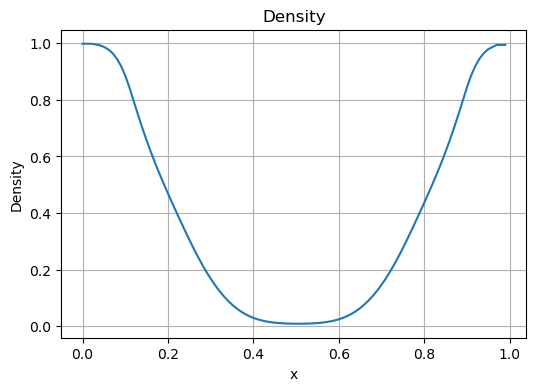

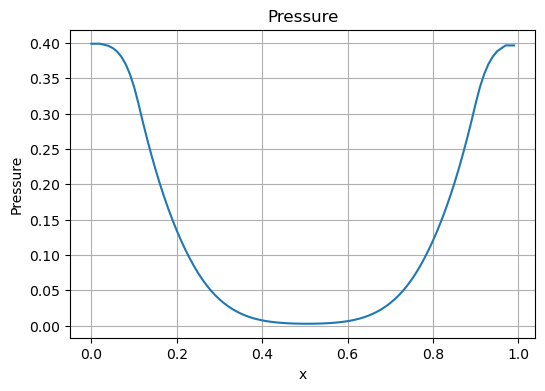

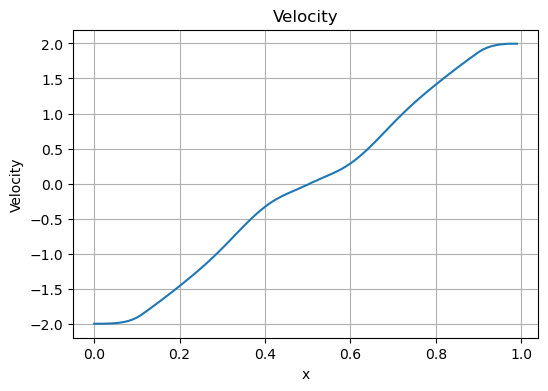

In [1]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
import rusanov_euler_eq_solver as r

gamma = 1.4
dt = 0.0001
N = 100
dx = 0.01
x = np.arange(N) * dx
t = 0.0
t_end = 0.15

solver = r.Rusanov_Euler_Eq_Solver(dt=dt, dx=dx, gamma=gamma)

# Conserved variables: density, momentum, and total energy.
U = np.zeros((N, 3))

# Symmetric initial condition with two flows moving towards each other.
for i in range(N):

    if x[i] <= 0.5:
        rho = 1.0
        v = -2.0
        p = 0.4
    else:
        rho = 1.0
        v = 2.0
        p = 0.4

    momentum = rho * v

    # Total energy density from pressure and kinetic energy.
    E = p / (gamma - 1) + 0.5 * rho * v**2

    U[i] = [rho, momentum, E]

# Evolve the solution until the final time.
while t < t_end:
    U = solver.time_step(U)
    t += dt

# Convert the conserved variables back to physical variables.
rho = U[:, 0]
momentum = U[:, 1]
E = U[:, 2]

v = momentum / rho
p = (gamma - 1) * (E - momentum**2 / (2 * rho))

# Density
plt.figure(figsize=(6, 4))
plt.plot(x, rho)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Density")
plt.grid()
plt.show()

# Pressure
plt.figure(figsize=(6, 4))
plt.plot(x, p)
plt.xlabel("x")
plt.ylabel("Pressure")
plt.title("Pressure")
plt.grid()
plt.show()

# Velocity
plt.figure(figsize=(6, 4))
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("Velocity")
plt.title("Velocity")
plt.grid()
plt.show()

